hw 5
====

In [1]:
# -------- Standard library --------
import os
import time
import random
from collections import Counter

# Quiet TensorFlow logs (set BEFORE importing TF)
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

# -------- Third-party --------
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import kagglehub

import tensorflow as tf
from tensorflow.keras import layers,models, callbacks, regularizers, initializers
from tensorflow.keras.callbacks import Callback,EarlyStopping,ReduceLROnPlateau
from tensorflow.keras.layers import (
    BatchNormalization,
    Conv2D,
    Dense,
    Dropout,
    Flatten,
    GlobalAveragePooling2D,
    GlobalMaxPooling2D,
    Input,
    MaxPooling2D,
    ReLU,
    SeparableConv2D,
)

from tensorflow.keras.applications import mobilenet_v2
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input
from tensorflow.keras.optimizers import Adam, AdamW
from tensorflow.keras.preprocessing.image import load_img, img_to_array



he = initializers.HeNormal()
l2reg = regularizers.l2(1e-4)

# Reproducibility settings
# -------------------------
random_seed = 42
random.seed(random_seed)
np.random.seed(random_seed)
tf.keras.utils.set_random_seed(random_seed)

def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))


---

# premade functions

In [2]:
def plot_learning_curves(hist, title, verbose=True):
    
    val_losses = hist.history['val_loss']
    min_val_loss = min(val_losses)
    min_val_epoch = val_losses.index(min_val_loss)
    val_acc_at_min_loss = hist.history['val_accuracy'][min_val_epoch]

    epochs = range(1, len(val_losses) + 1)  # epoch numbers starting at 1

    fig, axs = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

    # --- Loss Plot ---
    axs[0].plot(epochs, hist.history['loss'], label='train loss')
    axs[0].plot(epochs, hist.history['val_loss'], label='val loss')
    axs[0].scatter(min_val_epoch + 1, min_val_loss, color='red', marker='x', s=50, label='min val loss')
    axs[0].set_title(f'{title} - Categorical Cross-Entropy Loss')
    axs[0].set_ylabel('Loss')
    axs[0].legend()
    axs[0].grid(True)

    # --- Accuracy Plot ---
    axs[1].plot(epochs, hist.history['accuracy'], label='train acc')
    axs[1].plot(epochs, hist.history['val_accuracy'], label='val acc')
    axs[1].scatter(min_val_epoch + 1, val_acc_at_min_loss, color='red', marker='x', s=50, label='acc @ min val loss')
    axs[1].set_title(f'{title} - Accuracy')
    axs[1].set_xlabel('Epoch')
    axs[1].set_ylabel('Accuracy')
    axs[1].legend()
    axs[1].grid(True)
    axs[1].set_ylim(0, 1.05)

    plt.tight_layout()
    plt.show()

    if verbose:
        print(f"Final Training Loss:            {hist.history['loss'][-1]:.4f}")
        print(f"Final Training Accuracy:        {hist.history['accuracy'][-1]:.4f}")
        print(f"Final Validation Loss:          {hist.history['val_loss'][-1]:.4f}")
        print(f"Final Validation Accuracy:      {hist.history['val_accuracy'][-1]:.4f}")
        print(f"Minimum Validation Loss:        {min_val_loss:.4f} (Epoch {min_val_epoch + 1})")
        print(f"Validation Accuracy @ Min Loss: {val_acc_at_min_loss:.4f}")

    results[title] = (val_acc_at_min_loss,min_val_epoch + 1)

results = {}



In [3]:
def print_results():
    for title, (acc, ep) in sorted(results.items(), 
                                   key=lambda kv: kv[1][0],   # kv[1] is (acc, epoch); [0] is acc
                                   reverse=True
                                  ):
        print(f"{title:<40}\t{acc:.4f}\t{ep}")

In [4]:
def train_and_test(model, 
                   epochs=500,
                   lr_schedule=1e-3,
                   optimizer="Adam",
                   title="Learning Curves",
                   batch_size=64,  # kept for API compatibility; ignored if datasets are batched
                   use_early_stopping=True,
                   patience=8,
                   min_delta=1e-4,
                   callbacks=None,
                   verbose=1,
                   return_history=False):

    print(f"\n{title}\n")

    # Choose optimizer
    if optimizer == "Adam":
        opt = Adam(learning_rate=lr_schedule)
    else:
        opt = optimizer  # assume already an optimizer instance

    # Compile
    model.compile(
        optimizer=opt,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=patience,
        min_delta=min_delta,
        restore_best_weights=True,
        verbose=verbose
    )

    extra_cbs = callbacks or []
    cbs = ([early_stop] if use_early_stopping else []) + extra_cbs

    start = time.time()

    history = model.fit(
        train_ds,
        epochs=epochs,
        validation_data=val_ds,
        callbacks=cbs,
        verbose=verbose
    )

    # Best epoch consistent with EarlyStopping monitor
    best_epoch = int(np.argmin(history.history["val_loss"]))
    best_acc   = history.history["val_accuracy"][best_epoch]

    plot_learning_curves(history, title=title)

    test_loss, test_accuracy = model.evaluate(test_ds, verbose=0)

    print(f"\nTest Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_accuracy:.4f}")
    print(f"\nValidation-Test Gap (accuracy): {abs(best_acc - test_accuracy):.6f}")

    end = time.time()
    print(f"\nExecution Time: " + format_hms(end - start))

    if return_history:
        return history


## prepare dataset

In [5]:
path      = kagglehub.dataset_download("puneet6060/intel-image-classification")
train_dir = os.path.join(path, "seg_train/seg_train")
test_dir  = os.path.join(path, "seg_test/seg_test")

<div style="border:1.5px solid #aaa; border-radius:3em; padding: 1.2em">

#### data size draft
</div>

In [6]:
DATA_FRACTION = 0.25

AUTOTUNE = tf.data.AUTOTUNE

In [7]:
def stratified_subsample(filepaths, labels, fraction=1.0, seed=42):
    """
    Keep the same fraction of examples from each class.
    fraction=1.0 uses the complete dataset.
    """
    if fraction >= 1.0:
        return filepaths, labels

    rng = np.random.default_rng(seed)

    keep_idx = []

    for c in np.unique(labels):
        idx = np.flatnonzero(labels == c)
        rng.shuffle(idx)

        n_keep = max(1, int(len(idx) * fraction))
        keep_idx.extend(idx[:n_keep])

    keep_idx = np.array(keep_idx)
    rng.shuffle(keep_idx)

    return filepaths[keep_idx], labels[keep_idx]



In [8]:
def list_files_and_labels(directory, class_names=None, exts=(".jpg", ".jpeg", ".png")):
    """
    Returns:
      filepaths: np.array[str]
      labels:    np.array[int32]
      class_names_used: list[str] in deterministic order
    """
    if class_names is None:
        class_names = sorted(
            d for d in os.listdir(directory)
            if os.path.isdir(os.path.join(directory, d))
        )
    else:
        # keep only classes that exist in this directory, preserve given order
        class_names = [c for c in class_names if os.path.isdir(os.path.join(directory, c))]

    class_to_idx = {name: idx for idx, name in enumerate(class_names)}

    filepaths = []
    labels = []

    for cname in class_names:
        folder = os.path.join(directory, cname)
        for fname in sorted(os.listdir(folder)):  # deterministic within class
            if fname.lower().endswith(exts):
                filepaths.append(os.path.join(folder, fname))
                labels.append(class_to_idx[cname])

    return np.array(filepaths), np.array(labels, dtype=np.int32), class_names




In [9]:
def stratified_split_indices(y, val_frac=0.2, seed=42):
    """
    Deterministic stratified split over indices.
    Returns: train_idx, val_idx (np arrays)
    """
    rng = np.random.default_rng(seed)
    y = np.asarray(y)
    n = len(y)

    train_idx_list = []
    val_idx_list = []

    classes = np.unique(y)
    for c in classes:
        idx = np.flatnonzero(y == c)
        rng.shuffle(idx)
        n_val = int(np.floor(len(idx) * val_frac))
        val_idx_list.append(idx[:n_val])
        train_idx_list.append(idx[n_val:])

    train_idx = np.concatenate(train_idx_list)
    val_idx = np.concatenate(val_idx_list)

    # Optional: shuffle each split deterministically so batches mix classes
    rng.shuffle(train_idx)
    rng.shuffle(val_idx)

    return train_idx, val_idx




In [10]:
def make_image_dataset(filepaths, labels, img_size=(150, 150), batch_size=32,
                       shuffle=False, seed=42, cache_to_disk=None):
    """
    Builds a tf.data.Dataset that loads images lazily from disk.
    - filepaths: np array of strings
    - labels:    np array of int32
    """
    ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))

    if shuffle:
        # shuffle file *references* (cheap), not image tensors
        ds = ds.shuffle(buffer_size=len(filepaths), seed=seed, reshuffle_each_iteration=True)

    def _load_and_preprocess(path, label):
        # read bytes -> decode -> resize -> float32 -> MobileNetV2 preprocessing
        img_bytes = tf.io.read_file(path)
        img = tf.image.decode_image(img_bytes, channels=3, expand_animations=False)
        img = tf.image.resize(img, img_size, method="bilinear")
        img = tf.cast(img, tf.float32)
        img = preprocess_input(img)
        return img, label

    ds = ds.map(_load_and_preprocess, num_parallel_calls=AUTOTUNE)

    if cache_to_disk is not None:
        # Disk caching avoids RAM blowups; /tmp is fine in Colab
        ds = ds.cache(cache_to_disk)

    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds



In [11]:
def show_counts_from_labels(name, labels, class_names):
    c = Counter(labels.tolist())
    counts = {class_names[k]: c.get(k, 0) for k in range(len(class_names))}
    print(f"{name} per-class counts:", counts)


In [12]:
def make_base_model_pooled(trainable=False):
    base = mobilenet_v2.MobileNetV2(
        weights="imagenet",
        include_top=False,
        input_shape=INPUT_SHAPE,
        pooling="avg",
    )
    base.trainable = trainable
    return base


#### data split

In [13]:

# -------------------------
# Example usage for Intel dataset
# -------------------------

IMG_SIZE      = (150, 150)
INPUT_SHAPE   = IMG_SIZE + (3,)
BATCH_SIZE    = 32
VAL_FRAC      = 0.2
SEED          = random_seed  # use your existing seed


# 1) List train files/labels deterministically
train_files, train_labels, class_names = list_files_and_labels(train_dir)

num_classes = len(class_names)

# Optional: use a smaller stratified subset while developing/debugging
train_files, train_labels = stratified_subsample(
    train_files,
    train_labels,
    fraction=DATA_FRACTION,
    seed=SEED,
)

# 2) Stratified deterministic train/validation split
train_idx, val_idx = stratified_split_indices(
    train_labels,
    val_frac=VAL_FRAC,
    seed=SEED,
)

# 3) Slice file lists
files_train = train_files[train_idx]
y_train     = train_labels[train_idx]

files_val   = train_files[val_idx]
y_val       = train_labels[val_idx]

# 4) Build datasets
train_ds = make_image_dataset(
    files_train,
    y_train,
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
    cache_to_disk=None,
)

val_ds = make_image_dataset(
    files_val,
    y_val,
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    cache_to_disk=None,
)

# 5) Test set
test_files, test_labels, _ = list_files_and_labels(
    test_dir,
    class_names=class_names,
)

# Use the same fraction for quick development runs
test_files, test_labels = stratified_subsample(
    test_files,
    test_labels,
    fraction=DATA_FRACTION,
    seed=SEED,
)

test_ds = make_image_dataset(
    test_files,
    test_labels,
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    cache_to_disk=None,
)



print("class_names:", class_names)
print("train examples:", len(files_train), "val examples:", len(files_val), "test examples:", len(test_files))

show_counts_from_labels("train", y_train, class_names)
show_counts_from_labels("val",   y_val,   class_names)
show_counts_from_labels("test",  test_labels, class_names)


class_names: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
train examples: 2807 val examples: 699 test examples: 748
train per-class counts: {'buildings': 438, 'forest': 454, 'glacier': 481, 'mountain': 503, 'sea': 455, 'street': 476}
val per-class counts: {'buildings': 109, 'forest': 113, 'glacier': 120, 'mountain': 125, 'sea': 113, 'street': 119}
test per-class counts: {'buildings': 109, 'forest': 118, 'glacier': 138, 'mountain': 131, 'sea': 127, 'street': 125}


----

# p0

In [14]:

base = make_base_model_pooled()

print("Some statistics on the model:")
print("Total Keras layers:", len(base.layers))

# Count unique inverted-residual blocks by their prefix 'block_<n>'
block_ids = sorted({
    int(layer.name.split("_")[1])
    for layer in base.layers
    if layer.name.startswith("block_")
})
print("Conv Block IDs:", block_ids, "(count:", len(block_ids), ")")

# Check whether the final Conv_1 stage exists
has_conv1 = any(
    layer.name.startswith("Conv_1")
    for layer in base.layers
)

print("Has Conv_1 stage:", has_conv1)
print("Model Output Shape:", base.output_shape)

/tmp/ipykernel_1154/3314282633.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(


Some statistics on the model:
Total Keras layers: 155
Conv Block IDs: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16] (count: 16 )
Has Conv_1 stage: True
Model Output Shape: (None, 1280)


In [15]:
# base.summary()

## Base model

/tmp/ipykernel_1154/3314282633.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



Model Baseline

Epoch 1/500


/home/primary-a/miniconda3/envs/tf/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


88/88 ━━━━━━━━━━━━━━━━━━━━ 26s 171ms/step - accuracy: 0.7745 - loss: 0.6054 - val_accuracy: 0.8655 - val_loss: 0.3439
Epoch 2/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.8938 - loss: 0.2870 - val_accuracy: 0.8712 - val_loss: 0.3272
Epoch 3/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9177 - loss: 0.2305 - val_accuracy: 0.8684 - val_loss: 0.3280
Epoch 4/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9320 - loss: 0.1923 - val_accuracy: 0.8784 - val_loss: 0.3534
Epoch 5/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.9398 - loss: 0.1720 - val_accuracy: 0.8798 - val_loss: 0.3262
Epoch 6/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9540 - loss: 0.1382 - val_accuracy: 0.8755 - val_loss: 0.3330
Epoch 7/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9597 - loss: 0.1272 - val_accuracy: 0.8856 - val_loss: 0.3227
Epoch 8/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9686 - loss: 0.1107 - val_accuracy: 0.8813 - val

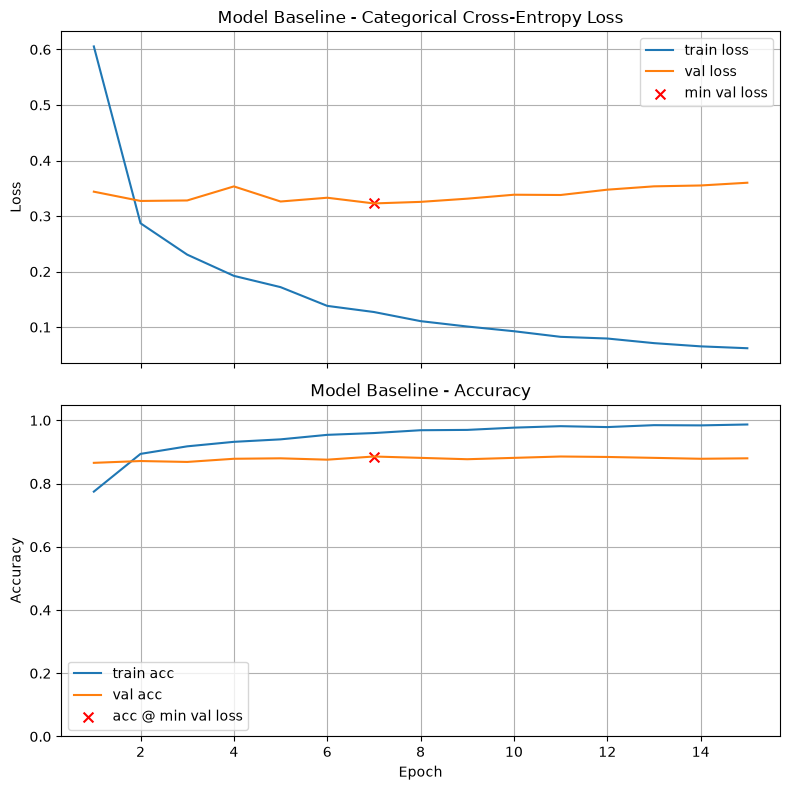

Final Training Loss:            0.0619
Final Training Accuracy:        0.9868
Final Validation Loss:          0.3600
Final Validation Accuracy:      0.8798
Minimum Validation Loss:        0.3227 (Epoch 7)
Validation Accuracy @ Min Loss: 0.8856

Test Loss: 0.2644
Test Accuracy: 0.8957

Validation-Test Gap (accuracy): 0.010171

Execution Time: 00:00:51


In [16]:
base_model = make_base_model_pooled()

model_baseline = models.Sequential([
    base_model,
    Dense(num_classes, activation='softmax')  # use your Intel num_classes (6)
])

train_and_test(model_baseline, title="Model Baseline")

In [17]:
reduce_lr = ReduceLROnPlateau(
        monitor = 'val_loss',
        factor = 0.5 ,
        patience = 3, 
        min_delta = 1e-4, 
        cooldown = 0, 
        min_lr = 1e-7,
        verbose = 0
)

---

# <b> p1

- change header

In [18]:
def p1_buildmodel(
        backbone,
        head_config, 
        l2_reg = None, 
):
    model = models.Sequential([backbone])

    l2reg = tf.keras.regularizers.L2(l2_reg) if l2_reg else None

    for layer_cfg in head_config:
        if layer_cfg["type"] == "dense":
            model.add(tf.keras.layers.Dense(
                units=layer_cfg["units"],
                activation="relu",
                kernel_regularizer=l2reg
            ))

        #     model.add(tf.keras.layers.Dense(
        #     units=layer_cfg["units"],
        #     activation=None,  # ReLU happens after normalization
        #     use_bias=False,
        #     kernel_regularizer=tf.keras.regularizers.L2(l2_reg)
        # ))

        #     model.add(tf.keras.layers.BatchNormalization())
        #     model.add(tf.keras.layers.Activation("relu"))

        elif layer_cfg["type"] == "dropout":
            model.add(tf.keras.layers.Dropout(
                rate=layer_cfg["rate"]
            ))

        else:
            raise ValueError(f"Unknown layer type: {layer_cfg['type']}")

    model.add(tf.keras.layers.Dense(
        num_classes,
        activation="softmax"
    ))

    return model




In [19]:
p1_head_configs = {
    "small": [
        {"type": "dense",   "units": 128},
        {"type": "dropout", "rate": 0.3},
    ],
    "larger": [
        {"type": "dense",   "units": 256},
        {"type": "dropout", "rate": 0.3},
        {"type": "dense",   "units": 128},
        {"type": "dropout", "rate": 0.3},
    ],
    "smaller_do": [
        {"type": "dense",   "units": 128},
        {"type": "dropout", "rate": 0.1},
    ],
}

p1_experiments = {
    "p1- small head - base LR 1e-3":    dict(
                                        head="small",  
                                        lr=1e-3, 
                                        earlystop = True,
                                        reduceLR = False,
                                        l2_reg=None),

    "p1- larger head - base LR 1e-3":   dict(
                                        head="small",  
                                        lr=1e-3, 
                                        earlystop = True,
                                        reduceLR = False,
                                        l2_reg=None),    

    "p1- small do head - base LR 1e-3":    dict(
                                        head="smaller_do",  
                                        lr=1e-3, 
                                        earlystop = True,
                                        reduceLR = False,
                                        l2_reg=None),                                                           

    # "p1- small head - small_lower_lr":  dict(
    #                                     head="small",  
    #                                     lr=1e-4, 
    #                                     earlystop = True,
    #                                     reduceLR = False,
    #                                     l2_reg=None),

    # "p1- small head - small_l2":        dict(
    #                                     head="small",  
    #                                     lr=1e-3, 
    #                                     earlystop = True,
    #                                     reduceLR = False,
    #                                     l2_reg=1e-4),

    "p1- larger head - lr 1e-4, reduce LR, l2 reg":   dict(
                                        head="larger", 
                                        lr=1e-4, 
                                        earlystop = True,
                                        reduceLR = [reduce_lr],
                                        l2_reg=1e-5),
}

p1_histories = {}

/tmp/ipykernel_1154/3314282633.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



p1- small head - base LR 1e-3



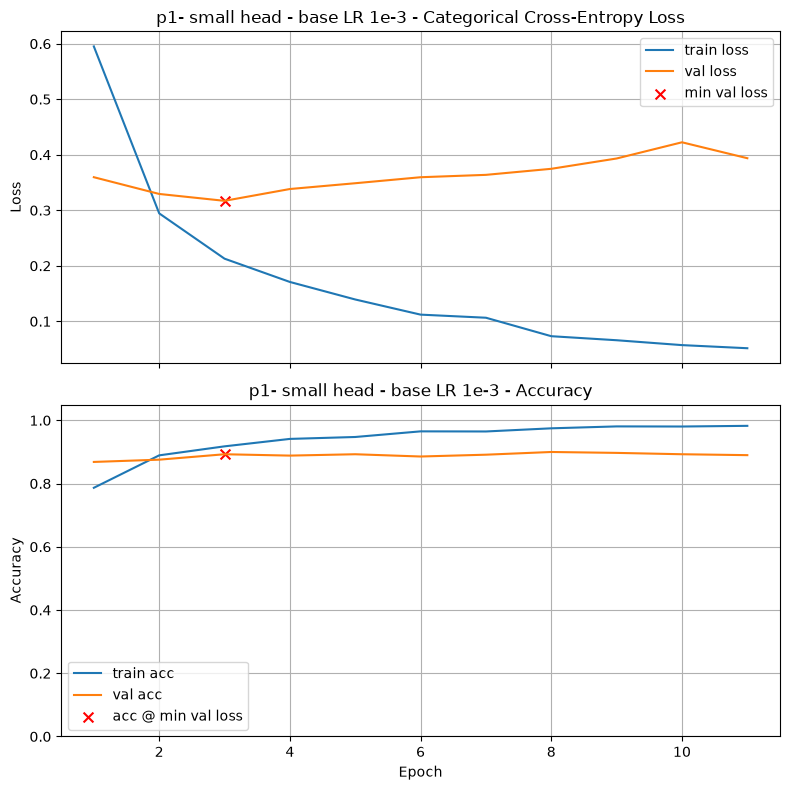

Final Training Loss:            0.0516
Final Training Accuracy:        0.9825
Final Validation Loss:          0.3938
Final Validation Accuracy:      0.8898
Minimum Validation Loss:        0.3170 (Epoch 3)
Validation Accuracy @ Min Loss: 0.8927

Test Loss: 0.2612
Test Accuracy: 0.9024

Validation-Test Gap (accuracy): 0.009703

Execution Time: 00:00:35

p1- larger head - base LR 1e-3



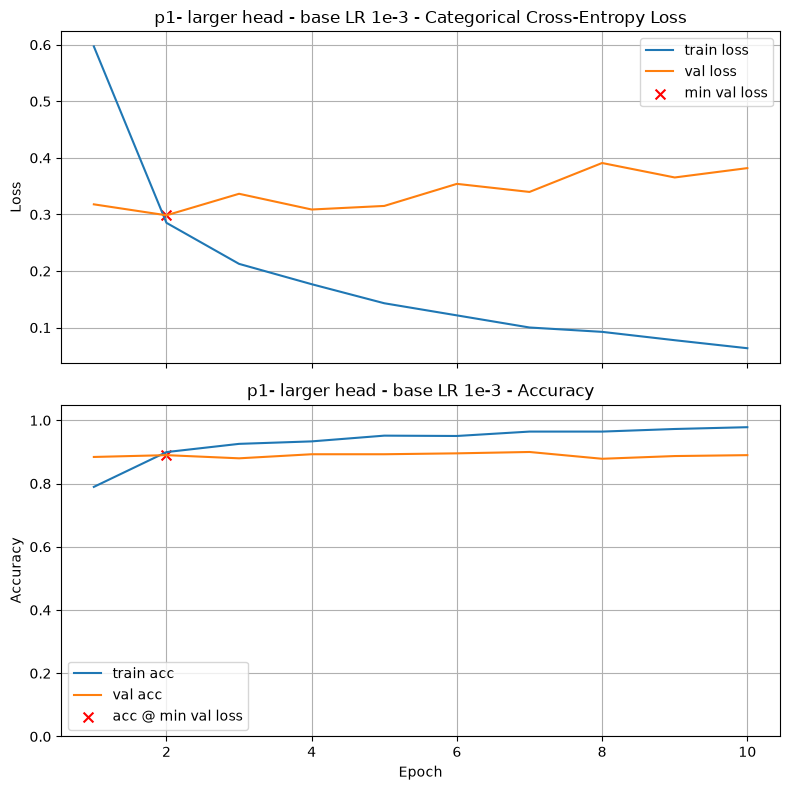

Final Training Loss:            0.0636
Final Training Accuracy:        0.9783
Final Validation Loss:          0.3819
Final Validation Accuracy:      0.8898
Minimum Validation Loss:        0.2986 (Epoch 2)
Validation Accuracy @ Min Loss: 0.8898

Test Loss: 0.2460
Test Accuracy: 0.9024

Validation-Test Gap (accuracy): 0.012564

Execution Time: 00:00:33

p1- small do head - base LR 1e-3



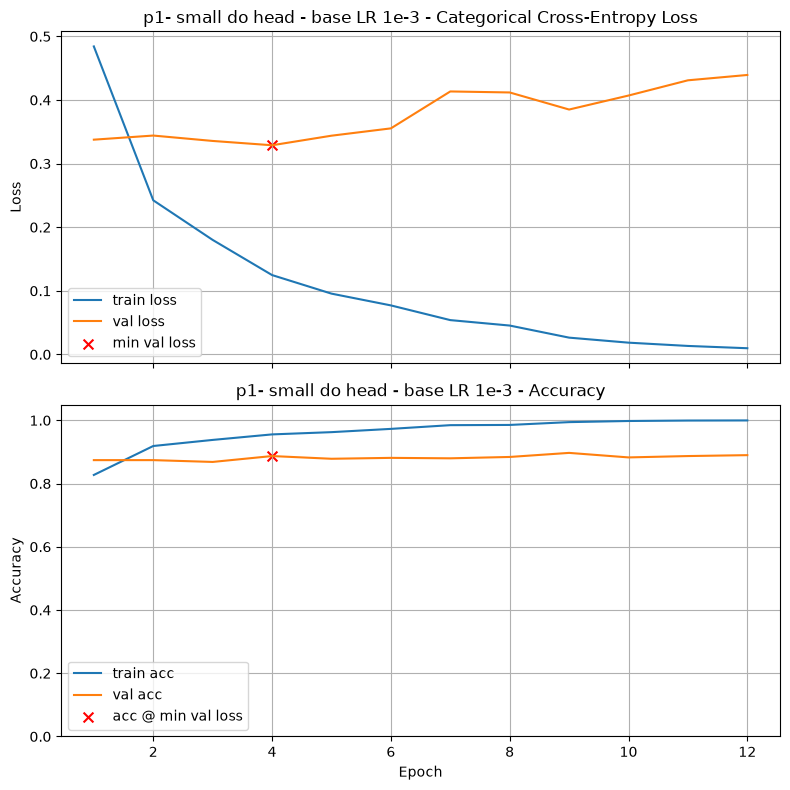

Final Training Loss:            0.0097
Final Training Accuracy:        0.9996
Final Validation Loss:          0.4394
Final Validation Accuracy:      0.8898
Minimum Validation Loss:        0.3288 (Epoch 4)
Validation Accuracy @ Min Loss: 0.8870

Test Loss: 0.2595
Test Accuracy: 0.9064

Validation-Test Gap (accuracy): 0.019436

Execution Time: 00:00:36

p1- larger head - lr 1e-4, reduce LR, l2 reg



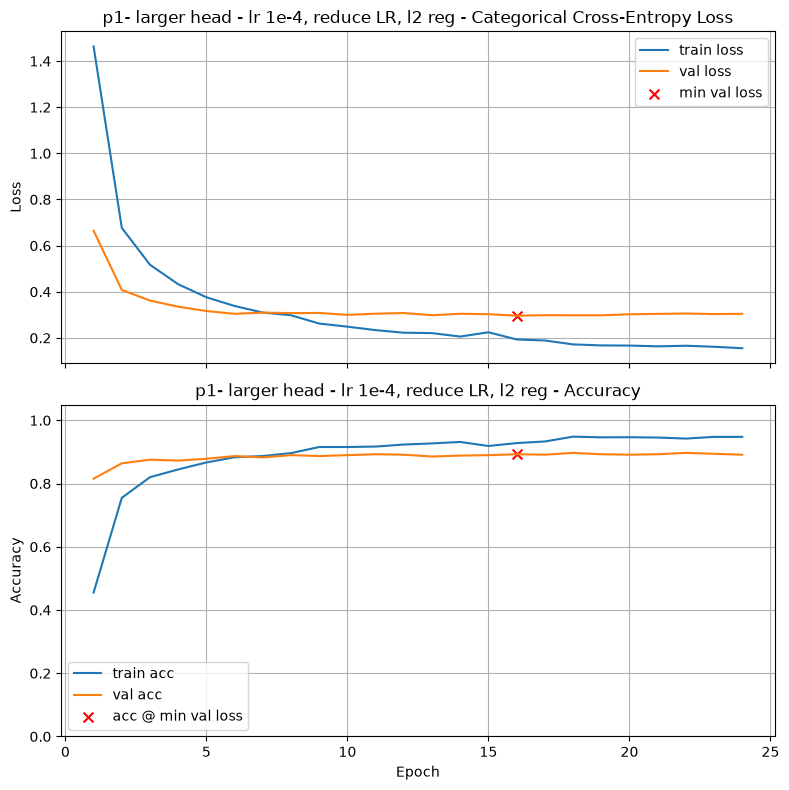

Final Training Loss:            0.1553
Final Training Accuracy:        0.9476
Final Validation Loss:          0.3045
Final Validation Accuracy:      0.8913
Minimum Validation Loss:        0.2964 (Epoch 16)
Validation Accuracy @ Min Loss: 0.8927

Test Loss: 0.2601
Test Accuracy: 0.9091

Validation-Test Gap (accuracy): 0.016387

Execution Time: 00:00:59


In [20]:
for title, config in p1_experiments.items():
    tf.keras.backend.clear_session()

    p1_model = p1_buildmodel(
        backbone=make_base_model_pooled(trainable=False),
        head_config=p1_head_configs[config["head"]],
        l2_reg=config["l2_reg"],
    )

    p1_hist = train_and_test(
        p1_model,
        lr_schedule = config["lr"],
        optimizer = "Adam",
        title = title, 
        use_early_stopping = config["earlystop"],
        callbacks = config["reduceLR"],
        verbose = 0,
        return_history = True
    )

    p1_histories[title] = p1_hist.history['val_accuracy']

    del p1_hist
    del p1_model



    

In [21]:
results

{'Model Baseline': (0.8855507969856262, 7),
 'p1- small head - base LR 1e-3': (0.8927038908004761, 3),
 'p1- larger head - base LR 1e-3': (0.8898426294326782, 2),
 'p1- small do head - base LR 1e-3': (0.8869814276695251, 4),
 'p1- larger head - lr 1e-4, reduce LR, l2 reg': (0.8927038908004761, 16)}

---

# p2

/tmp/ipykernel_1154/3314282633.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



p2- small head - base LR 1e-3



E0000 00:00:1791042939.953352    6160 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


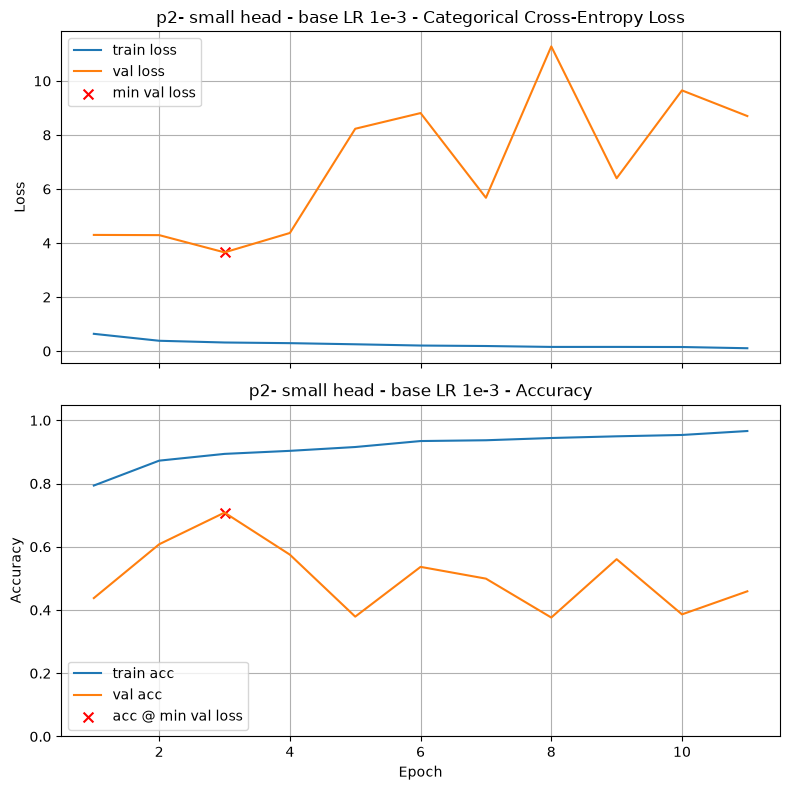

Final Training Loss:            0.1056
Final Training Accuracy:        0.9662
Final Validation Loss:          8.7005
Final Validation Accuracy:      0.4592
Minimum Validation Loss:        3.6537 (Epoch 3)
Validation Accuracy @ Min Loss: 0.7082

Test Loss: 4.0924
Test Accuracy: 0.6845

Validation-Test Gap (accuracy): 0.023663

Execution Time: 00:02:03

p2- larger head - base LR 1e-3



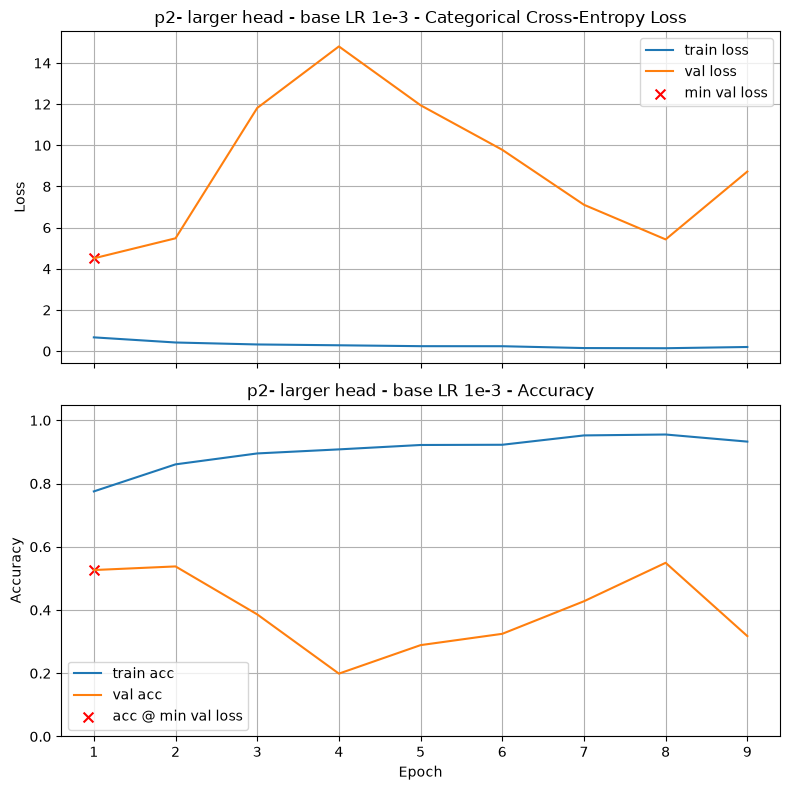

Final Training Loss:            0.2010
Final Training Accuracy:        0.9327
Final Validation Loss:          8.7262
Final Validation Accuracy:      0.3176
Minimum Validation Loss:        4.5092 (Epoch 1)
Validation Accuracy @ Min Loss: 0.5265

Test Loss: 4.7813
Test Accuracy: 0.5187

Validation-Test Gap (accuracy): 0.007750

Execution Time: 00:01:38


KeyError: 'smaller_do'

In [22]:
p2_head_configs = {
    "small": [
        {"type": "dense",   "units": 128},
        {"type": "dropout", "rate": 0.3},
    ],
    "larger": [
        {"type": "dense",   "units": 256},
        {"type": "dropout", "rate": 0.3},
        {"type": "dense",   "units": 128},
        {"type": "dropout", "rate": 0.3},
    ],
    # "smaller_do": [
    #     {"type": "dense",   "units": 128},
    #     {"type": "dropout", "rate": 0.1},
    # ],
}

p2_experiments = {
    "p2- small head - base LR 1e-3":    dict(
                                        head="small",  
                                        lr=1e-3, 
                                        earlystop = True,
                                        reduceLR = False,
                                        l2_reg=None),

    "p2- larger head - base LR 1e-3":   dict(
                                        head="small",  
                                        lr=1e-3, 
                                        earlystop = True,
                                        reduceLR = False,
                                        l2_reg=None),    

    "p2- small head - LR 1e-5":         dict(
                                        head="small",  
                                        lr=1e-5, 
                                        earlystop = True,
                                        reduceLR = False,
                                        l2_reg=None),                                                           

    "p2- small head - lr 1e-5, reduce LR, l2 reg":   dict(
                                        head="larger", 
                                        lr=1e-5, 
                                        earlystop = True,
                                        reduceLR = [reduce_lr],
                                        l2_reg=1e-5),
}

p2_histories = {}


for title, config in p2_experiments.items():
    tf.keras.backend.clear_session()

    p2_model = p1_buildmodel(
        backbone=make_base_model_pooled(trainable= True),
        head_config=p2_head_configs[config["head"]],
        l2_reg=config["l2_reg"],
    )

    p2_hist = train_and_test(
        p2_model,
        lr_schedule = config["lr"],
        optimizer = "Adam",
        title = title, 
        use_early_stopping = config["earlystop"],
        callbacks = config["reduceLR"],
        verbose = 0,
        return_history = True
    )

    p2_histories[title] = p2_hist.history['val_accuracy']

    del p2_hist
    del p2_model



    

In [23]:
results

{'Model Baseline': (0.8855507969856262, 7),
 'p1- small head - base LR 1e-3': (0.8927038908004761, 3),
 'p1- larger head - base LR 1e-3': (0.8898426294326782, 2),
 'p1- small do head - base LR 1e-3': (0.8869814276695251, 4),
 'p1- larger head - lr 1e-4, reduce LR, l2 reg': (0.8927038908004761, 16),
 'p2- small head - base LR 1e-3': (0.7081544995307922, 3),
 'p2- larger head - base LR 1e-3': (0.5264663696289062, 1)}

---

# p3

In [ ]:
def p3_unfreeze_some(
        basemodel, 
        n
):
    basemodel.trainable = True 

    for l in basemodel.layers[:-n]:
        l.trainable = False


#### ----------------------------------------------------- ####


p3_head_configs = {
    "small": [
        {"type": "dense",   "units": 128},
        {"type": "dropout", "rate": 0.3},
    ],
}



p3_experiments = {
    "p3-unfreeze n=20; small head LR 1e-3":    dict(
                                        head="small",  
                                        lr=1e-3, 
                                        earlystop = True,
                                        reduceLR = False,
                                        unfreeze_n = 20,
                                        l2_reg=None),

    "p3-unfreeze n=80;  small head LR 1e-3":    dict(
                                            head="small",  
                                            lr=1e-3, 
                                            earlystop = True,
                                            reduceLR = False,
                                            unfreeze_n = 80,
                                            l2_reg=None),

    "p3-unfreeze n=80;  small head LR 1e-4":    dict(
                                                head="small",  
                                                lr=1e-4, 
                                                earlystop = True,
                                                reduceLR = False,
                                                unfreeze_n = 80,
                                                l2_reg=None),

     "p3-unfreeze n=80;  small head LR 1e-3, reduce, L2 1e-4":    dict(
                                                 head="small",  
                                                 lr=1e-3, 
                                                 earlystop = True,
                                                 reduceLR = [reduce_lr],
                                                 unfreeze_n = 80,
                                                 l2_reg=1e-4),                               



}

for title, config in p3_experiments.items():
    tf.keras.backend.clear_session()

    basemodel = make_base_model_pooled()

    p3_model = p1_buildmodel(
        backbone=basemodel,
        head_config=p3_head_configs[config["head"]],
        l2_reg=config["l2_reg"],
    )

    p3_unfreeze_some(basemodel, config["unfreeze_n"])

    train_and_test(
        p3_model,
        lr_schedule = config["lr"],
        optimizer = "Adam",
        title = title, 
        use_early_stopping = config["earlystop"],
        callbacks = config["reduceLR"],
        verbose = 0,
        return_history = False
    )


    del basemodel
    del p3_model




---

# p4

In [ ]:
block_prefixes = [f"block_{i}" for i in range(1,17) ] + ["Conv_1"]

def belong_to_stage(layername, prefix):
    return layername == prefix or layername.startswith(prefix + "_")

def unfreeze_last_k_stages(base_model, k):
    ### notif
    if not 0 <= k <= len(block_prefixes):
        raise ValueError(f"k count")

                
           ##### •••••• ####

    selectedlayer = block_prefixes[-k:] if k > 0 else [] 

    base_model.trainable = True 

    for l in base_model.layers:
        if isinstance(l, tf.keras.layers.BatchNormalization):
            l.trainable = False
        else:
            l.trainable = any(belong_to_stage(l.name, p) for p in selectedlayer)

    ##------------
    trainable_names = [s.name for s in base_model.layers if s.trainable]

    return selectedlayer, trainable_names   


In [32]:
# base_model = make_base_model_pooled(trainable=False)
# selected, trainable_names = unfreeze_last_k_stages(base_model, k=3)

# print("Stages:", selected)
# print("Trainable layers:", trainable_names)
# print("Trainable backbone weights:", len(base_model.trainable_weights))

/tmp/ipykernel_1154/3314282633.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(


Stages: ['block_15', 'block_16', 'Conv_1']
Trainable layers: ['block_15_expand', 'block_15_expand_relu', 'block_15_depthwise', 'block_15_depthwise_relu', 'block_15_project', 'block_15_add', 'block_16_expand', 'block_16_expand_relu', 'block_16_depthwise', 'block_16_depthwise_relu', 'block_16_project', 'Conv_1']
Trainable backbone weights: 7


/tmp/ipykernel_1154/3314282633.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



p4-unfreeze Conv_1; base



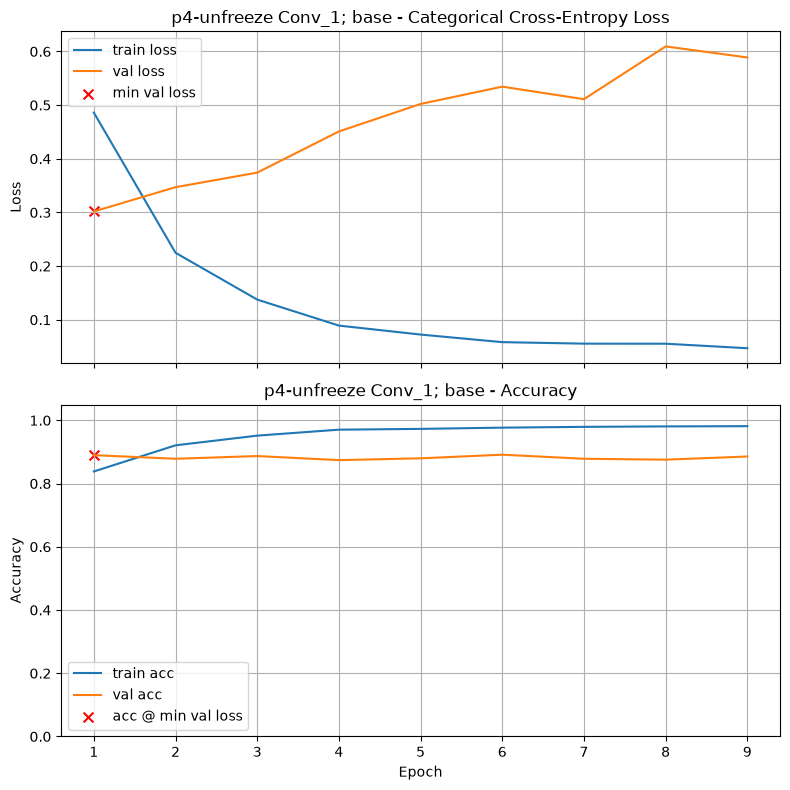

Final Training Loss:            0.0470
Final Training Accuracy:        0.9815
Final Validation Loss:          0.5888
Final Validation Accuracy:      0.8856
Minimum Validation Loss:        0.3018 (Epoch 1)
Validation Accuracy @ Min Loss: 0.8898

Test Loss: 0.2559
Test Accuracy: 0.9064

Validation-Test Gap (accuracy): 0.016575

Execution Time: 00:00:34

p4-unfreeze k=2; base



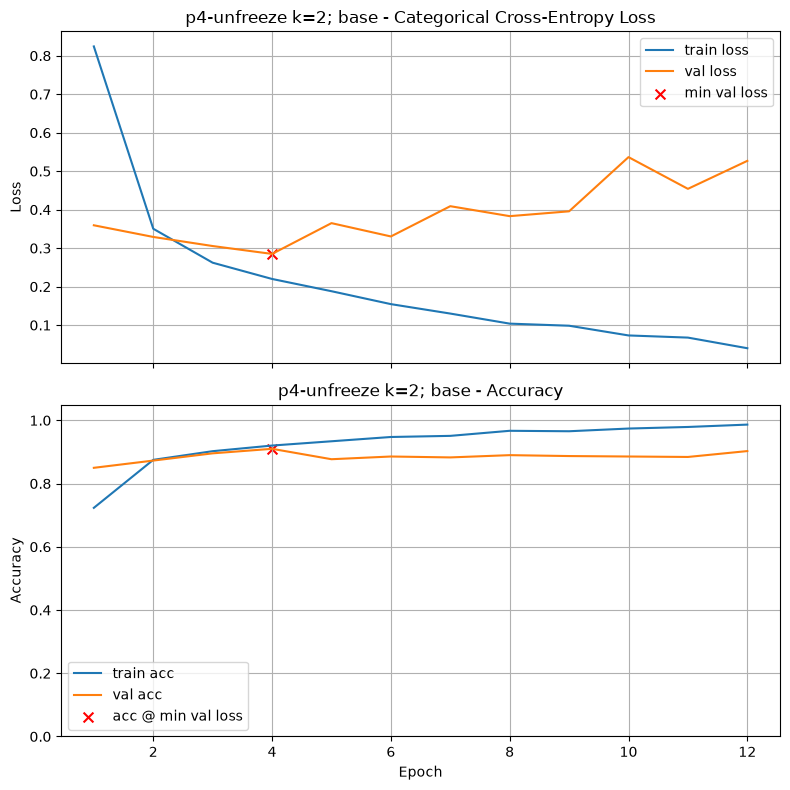

Final Training Loss:            0.0399
Final Training Accuracy:        0.9865
Final Validation Loss:          0.5268
Final Validation Accuracy:      0.9027
Minimum Validation Loss:        0.2850 (Epoch 4)
Validation Accuracy @ Min Loss: 0.9099

Test Loss: 0.2657
Test Accuracy: 0.9064

Validation-Test Gap (accuracy): 0.003454

Execution Time: 00:00:41

p4-unfreeze k=3; base



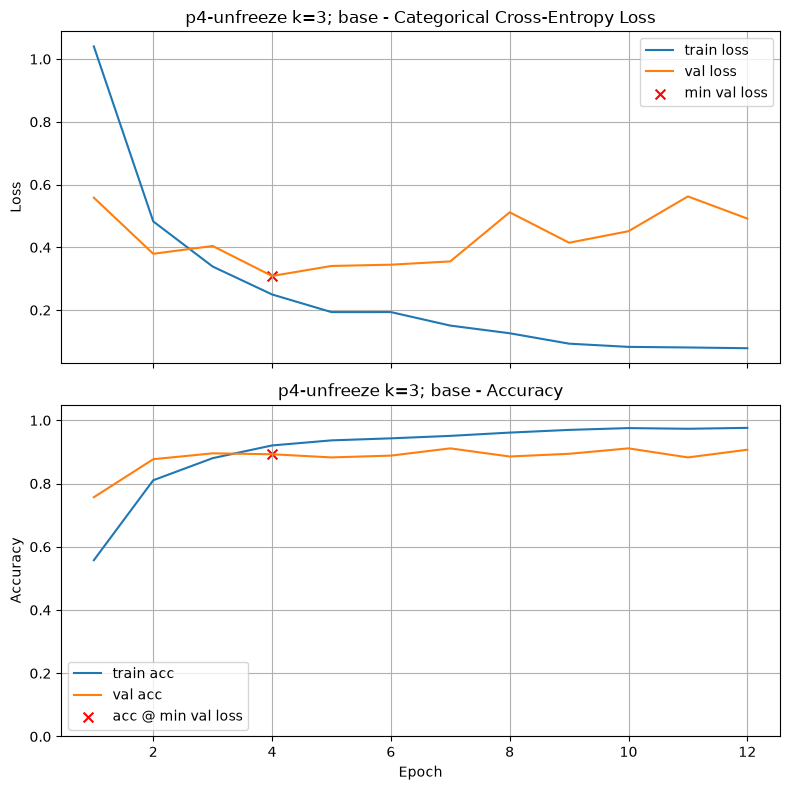

Final Training Loss:            0.0785
Final Training Accuracy:        0.9761
Final Validation Loss:          0.4917
Final Validation Accuracy:      0.9070
Minimum Validation Loss:        0.3088 (Epoch 4)
Validation Accuracy @ Min Loss: 0.8927

Test Loss: 0.3046
Test Accuracy: 0.8957

Validation-Test Gap (accuracy): 0.003018

Execution Time: 00:00:43


In [36]:
def p4_buildmodel(
        backbone,
        head_config, 
        l2_reg = None, 
        use_BN = False
):

    # backbone.trainable = False 
    
    model = models.Sequential([
        tf.keras.layers.Input(shape=INPUT_SHAPE),
        backbone
        ])

    l2reg = tf.keras.regularizers.L2(l2_reg) if l2_reg else None

    for layer_cfg in head_config:
        if layer_cfg["type"] == "dense":
            model.add(tf.keras.layers.Dense(
                units=layer_cfg["units"],
                activation=None,
                use_bias = not use_BN,
                kernel_regularizer=l2reg
            ))

            if use_BN:
                model.add(tf.keras.layers.BatchNormalization())

            model.add(tf.keras.layers.Activation("relu"))


        elif layer_cfg["type"] == "dropout":
            model.add(tf.keras.layers.Dropout(
                rate=layer_cfg["rate"]
            ))


    model.add(tf.keras.layers.Dense(
        num_classes,
        activation="softmax"
    ))

    return model



p4_head_configs = {
    "none" : [],

    "small": [
        {"type": "dense",   "units": 128},
        {"type": "dropout", "rate": 0.3},
    ],
}



p4_experiments = {
    ## --- base
    "p4-unfreeze Conv_1; base":    dict(
                                        head="none",  
                                        lr=1e-3, 
                                        earlystop = True,
                                        reduceLR = False,
                                        k_layer = 1,
                                        batch_norm_layer = False,
                                        l2_reg=None),

    "p4-unfreeze k=2; base":    dict(
                                            head="none",  
                                            lr=1e-3, 
                                            earlystop = True,
                                            reduceLR = False,
                                            k_layer = 2,
                                            batch_norm_layer = False,
                                            l2_reg=None),

    "p4-unfreeze k=3; base":    dict(
                                            head="none",  
                                            lr=1e-3, 
                                            earlystop = True,
                                            reduceLR = False,
                                            k_layer = 3,
                                            batch_norm_layer = False,
                                            l2_reg=None),    
## ------ change head
    "p4-unfreeze k=2; small head":    dict(
                                                head="small",  
                                                lr=1e-3, 
                                                earlystop = True,
                                                reduceLR = False,
                                                k_layer = 2,
                                                batch_norm_layer = False,
                                                l2_reg=None),

    "p4-unfreeze k=2; small head + BN":    dict(
                                                head="small",  
                                                lr=1e-3, 
                                                earlystop = True,
                                                reduceLR = False,
                                                k_layer = 2,
                                                batch_norm_layer = True,
                                                l2_reg=None),

    "p4-unfreeze k=2; small head, lr 1e-4":    dict(
                                                head="small",  
                                                lr=1e-4, 
                                                earlystop = True,
                                                reduceLR = False,
                                                k_layer = 2,
                                                batch_norm_layer = False,
                                                l2_reg=None),                                                                                                                                                                    

                              



}

for title, config in p4_experiments.items():
    tf.keras.backend.clear_session()

    basemodel = make_base_model_pooled(trainable= False)

    p4_model = p4_buildmodel(
        backbone=basemodel,
        head_config=p4_head_configs[config["head"]],
        l2_reg=config["l2_reg"],
        use_BN=config["batch_norm_layer"]
    )

    unfreeze_last_k_stages(basemodel, config["k_layer"])

    train_and_test(
        p4_model,
        lr_schedule = config["lr"],
        optimizer = "Adam",
        title = title, 
        use_early_stopping = config["earlystop"],
        callbacks = config["reduceLR"],
        verbose = 0,
        return_history = False
    )


    del basemodel
    del p4_model


---

# p5

In [37]:
print_results()

p4-unfreeze k=2; base                   	0.9099	4
p1- small head - base LR 1e-3           	0.8927	3
p1- larger head - lr 1e-4, reduce LR, l2 reg	0.8927	16
p4-unfreeze k=3; base                   	0.8927	4
p1- larger head - base LR 1e-3          	0.8898	2
p4-unfreeze Conv_1; base                	0.8898	1
p1- small do head - base LR 1e-3        	0.8870	4
Model Baseline                          	0.8856	7
p3 small head LR 1e-4 - n=20            	0.8298	1
p3 small head LR 1e-3 - n=20            	0.8183	1
p3 small head LR 1e-3, reduce, L2 1e-4 - n=20	0.7668	2
p3 small head LR 1e-3 - n=80            	0.7368	6
p2- small head - base LR 1e-3           	0.7082	3
p2- larger head - base LR 1e-3          	0.5265	1


---

# end
